# Proyecto Integrador Final
## Predicción de precios de viviendas

Este proyecto simula un caso profesional de Ciencia de Datos.  
El objetivo es estimar el precio de una vivienda a partir de sus características principales, utilizando un dataset sintético y un modelo simple de Machine Learning.

## 1. Importación de librerías


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

In [4]:
# Creamos un dataset ficticio de viviendas

np.random.seed(42)

cantidad = 100

df = pd.DataFrame({
    "superficie_m2": np.random.randint(40, 200, cantidad),
    "habitaciones": np.random.randint(1, 6, cantidad),
    "banios": np.random.randint(1, 4, cantidad),
    "antiguedad": np.random.randint(0, 40, cantidad),
    "cochera": np.random.choice([0, 1], cantidad)
})

# Creamos un precio simulado según las características
df["precio"] = (
    df["superficie_m2"] * 1200 +
    df["habitaciones"] * 15000 +
    df["banios"] * 20000 +
    df["cochera"] * 25000 -
    df["antiguedad"] * 800 +
    np.random.normal(0, 15000, cantidad)
)

df["precio"] = df["precio"].round(2)

df.head()

,superficie_m2,habitaciones,banios,antiguedad,cochera,precio
0,142,5,3,34,1,308630.21
1,132,3,2,36,1,248319.71
2,54,4,1,23,0,116954.49
3,146,3,3,28,0,270951.32
4,111,3,3,30,0,222476.06


In [5]:
# Revisamos información general del dataset

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   superficie_m2  100 non-null    int64  
 1   habitaciones   100 non-null    int64  
 2   banios         100 non-null    int64  
 3   antiguedad     100 non-null    int64  
 4   cochera        100 non-null    int64  
 5   precio         100 non-null    float64
dtypes: float64(1), int64(5)
memory usage: 4.8 KB


In [6]:
# Estadísticas principales

df.describe()

,superficie_m2,habitaciones,banios,antiguedad,cochera,precio
count,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
mean,113.140000,2.920000,1.990000,21.180000,0.560000,218195.943100
std,44.949359,1.433228,0.834787,11.543838,0.498888,66230.478045
min,41.000000,1.000000,1.000000,0.000000,0.000000,72648.030000
25%,78.500000,1.750000,1.000000,12.750000,0.000000,176195.942500
50%,111.000000,3.000000,2.000000,22.500000,1.000000,218180.570000
75%,147.750000,4.000000,3.000000,31.000000,1.000000,270172.162500
max,197.000000,5.000000,3.000000,39.000000,1.000000,368960.100000


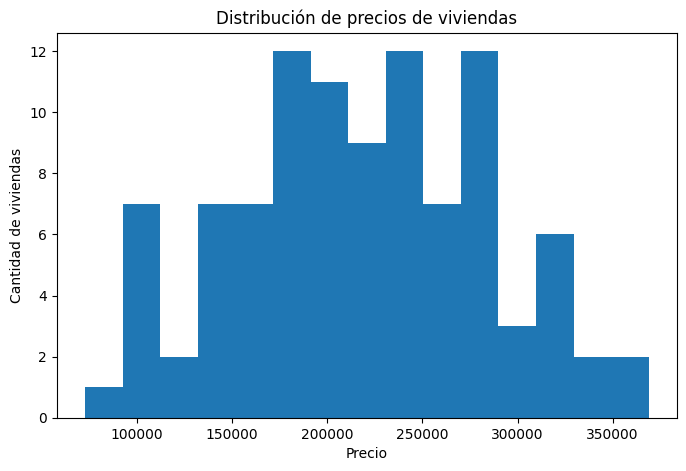

In [7]:
# Gráfico 1: distribución de precios

plt.figure(figsize=(8, 5))
plt.hist(df["precio"], bins=15)
plt.title("Distribución de precios de viviendas")
plt.xlabel("Precio")
plt.ylabel("Cantidad de viviendas")
plt.show()

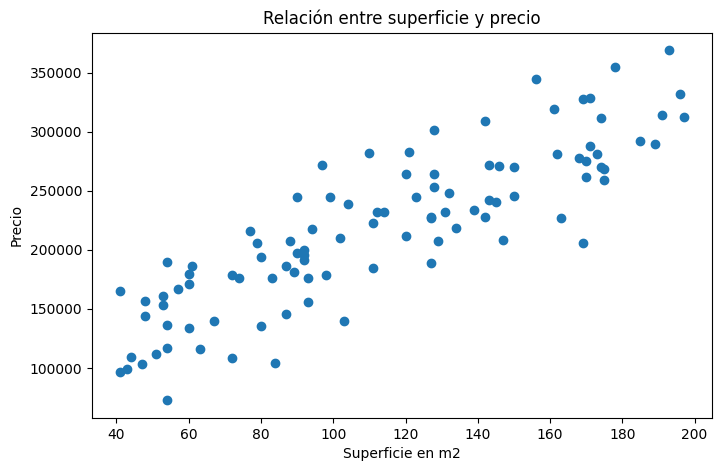

In [8]:
# Gráfico 2: relación entre superficie y precio

plt.figure(figsize=(8, 5))
plt.scatter(df["superficie_m2"], df["precio"])
plt.title("Relación entre superficie y precio")
plt.xlabel("Superficie en m2")
plt.ylabel("Precio")
plt.show()

In [9]:
# Separamos variables predictoras y variable objetivo

X = df[["superficie_m2", "habitaciones", "banios", "antiguedad", "cochera"]]
y = df["precio"]

# Dividimos datos en entrenamiento y prueba

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [10]:
# Entrenamos el modelo

modelo = LinearRegression()
modelo.fit(X_train, y_train)

# Realizamos predicciones

predicciones = modelo.predict(X_test)

In [12]:
# Evaluamos el modelo

mae = mean_absolute_error(y_test, predicciones)
r2 = r2_score(y_test, predicciones)

print("Resultados del modelo")
print(f"MAE: {mae:.2f}")
print(f"R2: {r2:.4f}")

Resultados del modelo
MAE: 12888.78
R2: 0.9484


In [13]:
# Comparamos precios reales vs predichos

resultados = pd.DataFrame({
    "precio_real": y_test.values,
    "precio_predicho": predicciones.round(2)
})

resultados.head(10)

,precio_real,precio_predicho
0,228149.88,202139.98
1,181562.95,167091.96
2,270136.02,267985.58
3,199601.67,176899.25
4,207236.59,222080.86
5,328257.34,329060.89
6,179884.76,154096.99
7,253370.21,249125.45
8,344892.90,320998.01
9,308630.21,302397.36


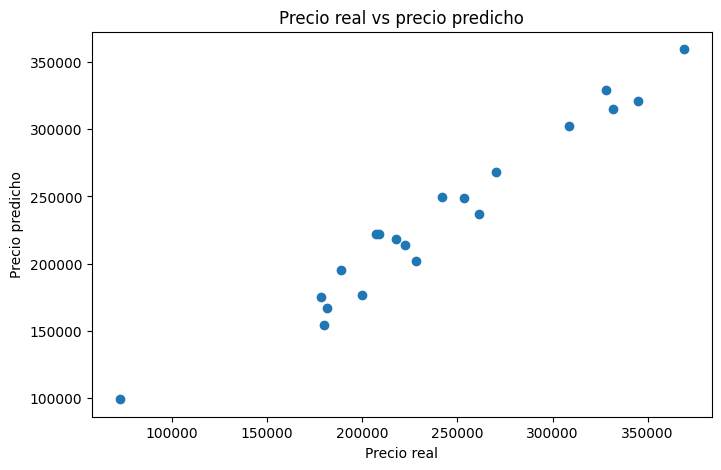

In [14]:
# Gráfico de comparación real vs predicho

plt.figure(figsize=(8, 5))
plt.scatter(y_test, predicciones)
plt.title("Precio real vs precio predicho")
plt.xlabel("Precio real")
plt.ylabel("Precio predicho")
plt.show()

In [15]:
# Ejemplo de predicción para una vivienda nueva

nueva_vivienda = pd.DataFrame({
    "superficie_m2": [85],
    "habitaciones": [3],
    "banios": [2],
    "antiguedad": [10],
    "cochera": [1]
})

precio_estimado = modelo.predict(nueva_vivienda)

print(f"Precio estimado de la vivienda: ${precio_estimado[0]:,.2f}")

Precio estimado de la vivienda: $204,333.38


In [16]:
# Guardamos el dataset para subirlo a GitHub

df.to_csv("viviendas_simuladas.csv", index=False)

## Conclusión

El modelo de Regresión Lineal permitió estimar el precio de viviendas a partir de variables como superficie, cantidad de habitaciones, baños, antigüedad y cochera.

Al tratarse de un dataset sintético, los resultados tienen fines académicos y no deben utilizarse para decisiones inmobiliarias reales. Sin embargo, el proyecto permite demostrar las etapas principales de un flujo de trabajo en Ciencia de Datos: generación de datos, análisis exploratorio, entrenamiento de modelo, evaluación y documentación.